In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
nav = pd.read_csv(
    "../Data/raw/02_nav_history.csv"
)

transactions = pd.read_csv(
    "../Data/raw/08_investor_transactions.csv"
)

performance = pd.read_csv(
    "../Data/raw/07_scheme_performance.csv"
)

In [3]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

returns = nav["daily_return"].dropna()

In [4]:
var95 = np.percentile(
    returns,
    5
)

print(
    "95% VaR:",
    round(var95 * 100, 2),
    "%"
)

95% VaR: -1.63 %


# Insight 1

The portfolio is expected to lose more than the VaR value on only 5% of trading days.

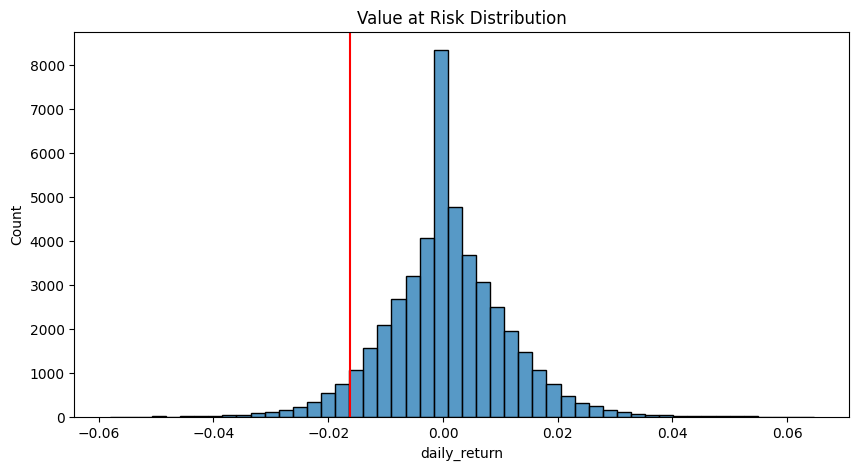

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    returns,
    bins=50
)

plt.axvline(
    var95,
    color="red"
)

plt.title(
    "Value at Risk Distribution"
)

plt.show()

In [6]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["cohort"] = (
    transactions["transaction_date"]
    .dt.to_period("M")
)

In [7]:
cohort = (
    transactions.groupby(
        ["cohort", "transaction_type"]
    )
    .size()
    .unstack(fill_value=0)
)

cohort.head()

transaction_type,Lumpsum,Redemption,SIP
cohort,,,
2024-01,492,311,1146
2024-02,439,268,1154
2024-03,498,299,1177
2024-04,484,282,1186
2024-05,438,308,1155


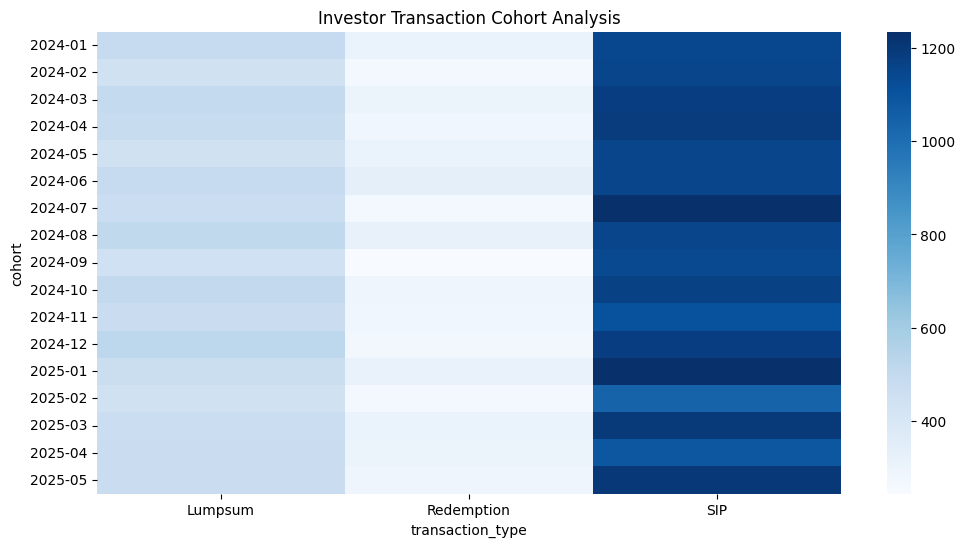

In [8]:
plt.figure(figsize=(12,6))

sns.heatmap(
    cohort,
    cmap="Blues"
)

plt.title(
    "Investor Transaction Cohort Analysis"
)

plt.show()

# Insight 2

Investor transaction behaviour varies across different monthly cohorts.

In [9]:
recommended = performance.sort_values(
    [
        "sharpe_ratio",
        "return_3yr_pct"
    ],
    ascending=False
).head(10)

recommended[
    [
        "scheme_name",
        "sharpe_ratio",
        "return_3yr_pct"
    ]
]

,scheme_name,sharpe_ratio,return_3yr_pct
14,ICICI Pru Liquid Fund - Regular - Growth,7.68,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84,7.37
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52,6.07
19,Nippon India Gilt Securities Fund - Regular - ...,1.33,5.31
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06,14.84
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06,14.81
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03,14.41
15,Nippon India Large Cap Fund - Regular - Growth,1.00,14.00


In [10]:
recommended.to_csv(
    "../reports/recommendations.csv",
    index=False
)

print(
    "recommendations.csv saved"
)

recommendations.csv saved


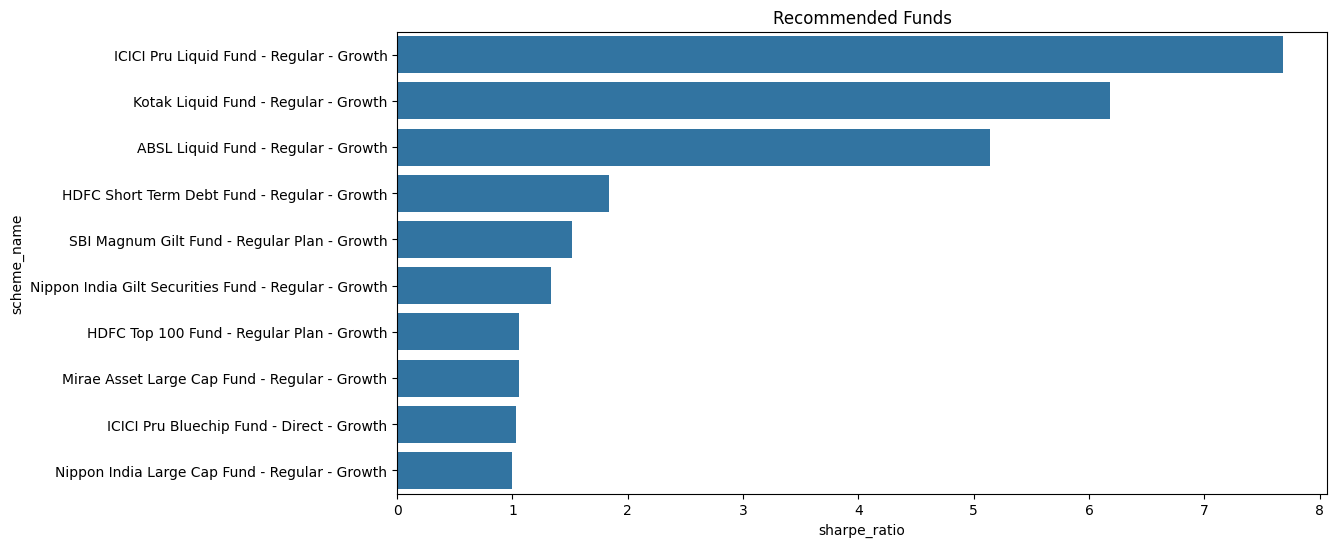

In [11]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=recommended,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title(
    "Recommended Funds"
)

plt.show()

# Insight 3

Funds with high Sharpe ratios and strong long-term returns are preferred recommendations.